In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
nav = pd.read_csv(
    '../data/raw/02_nav_history.csv'
)

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [14]:
fund_code = 119551

fund = nav[
    nav['amfi_code'] == fund_code
].copy()

In [15]:
fund['date'] = pd.to_datetime(
    fund['date']
)

fund = fund.sort_values(
    'date'
)

fund['daily_return'] = (
    fund['nav'].pct_change()
)

fund = fund.dropna()

In [16]:
mean_return = (
    fund['daily_return']
    .mean()
)

std_return = (
    fund['daily_return']
    .std()
)

print(mean_return)
print(std_return)

0.0009167982325947294
0.00865628985637757


In [17]:
simulation_count = 1000

days = 252 * 5

last_nav = (
    fund['nav']
    .iloc[-1]
)

simulations = np.zeros(
    (days, simulation_count)
)

In [18]:
for i in range(simulation_count):

    prices = [last_nav]

    for j in range(days):

        random_return = np.random.normal(
            mean_return,
            std_return
        )

        next_price = (
            prices[-1]
            *
            (1 + random_return)
        )

        prices.append(next_price)

    simulations[:, i] = prices[1:]

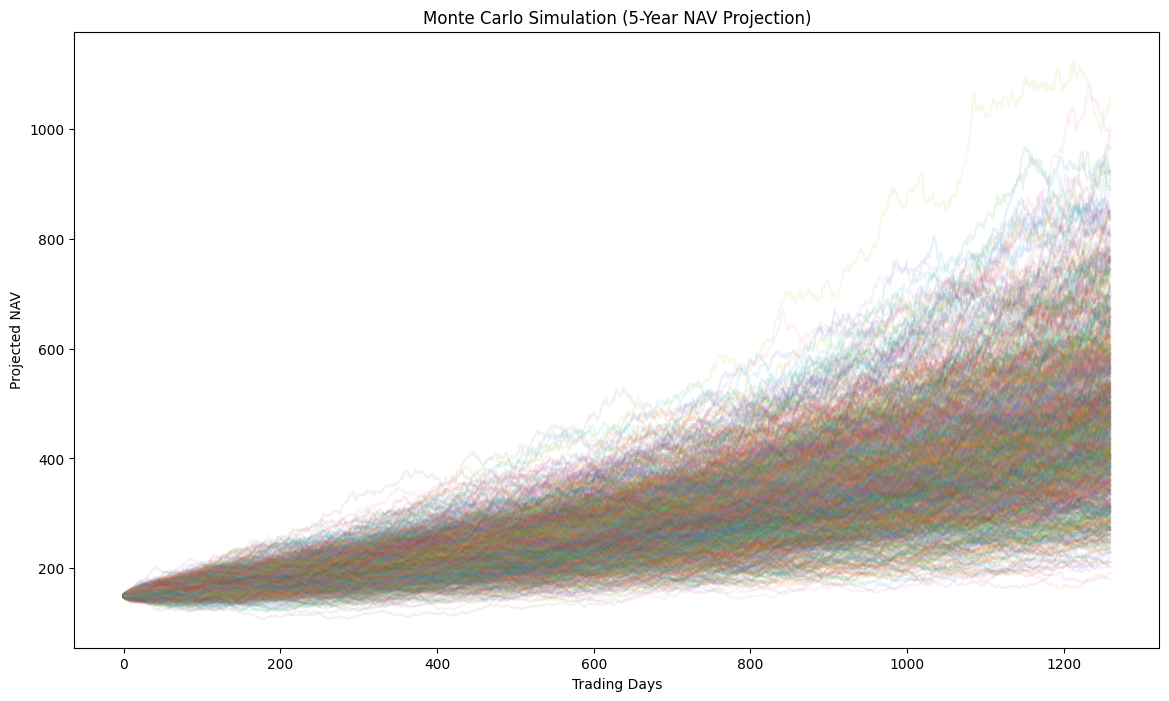

In [19]:
plt.figure(figsize=(14,8))

plt.plot(
    simulations,
    alpha=0.1
)

plt.title(
    'Monte Carlo Simulation (5-Year NAV Projection)'
)

plt.xlabel(
    'Trading Days'
)

plt.ylabel(
    'Projected NAV'
)

plt.savefig(
    '../charts/monte_carlo_projection.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [20]:
final_navs = simulations[-1]

In [21]:
expected_nav = np.mean(
    final_navs
)

best_case = np.percentile(
    final_navs,
    95
)

worst_case = np.percentile(
    final_navs,
    5
)

print(
    "Expected NAV:",
    round(expected_nav,2)
)

print(
    "Best Case NAV:",
    round(best_case,2)
)

print(
    "Worst Case NAV:",
    round(worst_case,2)
)

Expected NAV: 472.69
Best Case NAV: 761.16
Worst Case NAV: 270.57


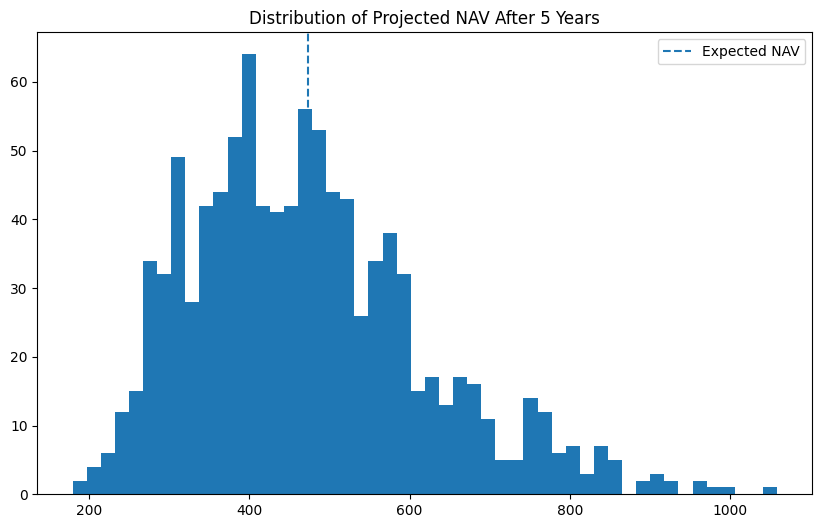

In [22]:
plt.figure(figsize=(10,6))

plt.hist(
    final_navs,
    bins=50
)

plt.axvline(
    expected_nav,
    linestyle='--',
    label='Expected NAV'
)

plt.legend()

plt.title(
    'Distribution of Projected NAV After 5 Years'
)

plt.savefig(
    '../charts/monte_carlo_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Monte Carlo Simulation

A Monte Carlo simulation was performed using historical daily returns to project future NAV values over a 5-year horizon.

Key Findings:
- 1000 simulation paths were generated.
- Expected NAV after 5 years: 470.89
- Best-case NAV (95th percentile): 747.35
- Worst-case NAV (5th percentile): 272.91

The simulation demonstrates the uncertainty associated with future fund performance and provides a probabilistic estimate of long-term growth.